# Using breads to fit example linear and gaussian data sets

This tutorial will teach you how to use breads to fit models to data by analytically marginalizing over linear parameters, enabling the evaluation of model probabilities without relying on computationally expensive MCMC methods. Through simple linear and Gaussian examples, you will learn how breads performs parameter estimation and how its grid-based approach compares to traditional posterior sampling techniques.

## Set-up

Import necessary modules from breads and packages

In [1]:
from breads.fit import fitfm
from breads.instruments import Instrument
from breads.grid_search import grid_search
import numpy as np
import matplotlib.pyplot as plt
import emcee

/Users/khorstman/opt/anaconda3/envs/breads-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Linear model fitting

First, we need to define the function for a line. Since the function for a line only contains linear parameters, no non-linear parameters are included. However, the `fitfm` function requires non-linear parameters, so we must include them in the definition of our line. 

The linear forward model function must return:

d: Data as a 1d vector with bad pixels removed (no nans)

M: Linear model as a matrix of shape (Nd,Np) with bad pixels removed (no nans). Nd is the size of the data vector and Np is the number of linear parameters.

s: Noise vector (standard deviation) as a 1d vector matching d.

See `breads.fm.template` for more information.

In [2]:
import numpy as np

def linear_fm_func(nonlin_paras, instrument: "Instrument", **fm_paras):
    """
    Build a linear forward model for an Instrument instance.
    
    Parameters
    ----------
    nonlin_paras : array-like
    Non-linear parameters (not used in this simple linear model,but kept for consistency).
    
    instrument : Instrument
    An instance of the Instrument class containing wavelengths and data.
        
    Returns
    -------
    y : np.ndarray
        The dependent variable (instrument data flattened).
    M : np.ndarray
        The design matrix for linear fitting (wavelengths and constant term).
    s : np.ndarray or None
        Uncertainties from instrument.noise, if available.
    """

    # Flatten the data for 1D linear fit
    y = instrument.data.flatten()
    x = instrument.wavelengths.flatten()
    
    s = instrument.noise.flatten()
    
    # Design matrix: linear term + constant
    M = np.vstack([x, np.ones_like(x)]).T
    
    return y, M, s

Next, we need to define our example data set. 

In [3]:
my_instrument = Instrument("example_instrument")

my_instrument.manual_data_entry(
    wavelengths=np.array([1,2,3,4,5]), 
    data=np.array([2.1,3.5,6.1,9.2,10.2]), 
    noise=np.ones(5)*0.3,
    bad_pixels=None,
    bary_RV=0
)

/Users/khorstman/breads/breads/instruments/instrument.py:55: UserWarning: when feeding data manually, ensure correct units. wavelengths in microns, bary_RV in km/s
  warn("when feeding data manually, ensure correct units. wavelengths in microns, bary_RV in km/s")


Finally, we need to use the `fitfm` function to return the best fit linear parameters.

In [4]:
results = fitfm(
    nonlin_paras=[],
    dataobj=my_instrument,
    fm_func=linear_fm_func,
    fm_paras={}
)

In [5]:
log_prob, log_prob_H0, rchi2, linparas, linparas_err = results

In [6]:
print("Slope (m):", linparas[0], "±", linparas_err[0])
print("Intercept (b):", linparas[1], "±", linparas_err[1])
print("Reduced chi2:", rchi2)

Slope (m): 2.189999999999999 ± 0.11986957920086994
Intercept (b): -0.3499999999999976 ± 0.39756241798707526
Reduced chi2: 2.548888888888885


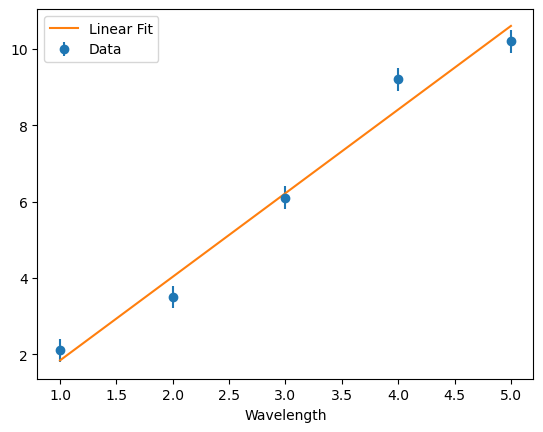

In [7]:
model = linparas[0] * my_instrument.wavelengths + linparas[1]

plt.errorbar(
    my_instrument.wavelengths, 
    my_instrument.data, 
    yerr=my_instrument.noise, 
    fmt='o', 
    label='Data'
)

plt.plot(my_instrument.wavelengths, model, label='Linear Fit')
plt.xlabel("Wavelength")
plt.legend()
plt.show()

## Gaussian model fitting

Now, we will define a a gaussian model with both linear and non-linear parameters. To keep it simple, we will fix sigma, or the standard deviation, so we only need to worry about one non-linear parameter. 

The gaussian function now has two parameters:

mu (mean): Non-linear

A (amplitude): Linear

In [20]:
import numpy as np

def gaussian_mu_only_fm_func(nonlin_paras, instrument, **fm_paras):
    """
    Linear forward model for a Gaussian with fixed sigma, fitting only mu.
    
    Parameters
    ----------
    nonlin_paras : list or array
    [mu] - the Gaussian center
    
    instrument : Instrument
    Instrument instance containing wavelengths, data, and noise
    
    fm_paras : dict
    Additional parameters, must include 'sigma'
        
    Returns
    -------
    y : np.ndarray
        The dependent variable (instrument data flattened).
    M : np.ndarray
        The design matrix for linear fitting (gaussian).
    s : np.ndarray or None
        Uncertainties from instrument.noise, if available.
    """
    # Extract mu and sigma
    mu = nonlin_paras[0]
    sigma = fm_paras["sigma"]

    x = instrument.wavelengths.flatten()
    y = instrument.data.flatten()
    s = instrument.noise.flatten()

    # Gaussian basis (linear in amplitude)
    A = np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    M = A[:, None] 

    return y, M, s

Next, we define the example gaussian data set.

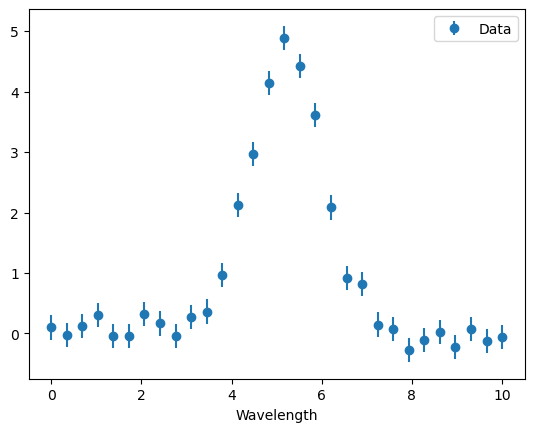

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate Gaussian data
x = np.linspace(0, 10, 30)
y = 5.0 * np.exp(-0.5 * ((x - 5.2) / 0.8) ** 2) + np.random.normal(0, 0.2, x.size)
s = np.ones_like(x) * 0.2

# Create an Instrument instance
my_instrument = Instrument("example_instrument")
my_instrument.manual_data_entry(
    wavelengths=x, 
    data=y,         
    noise=s,        
    bad_pixels=None,
    bary_RV=0
)

# Plot the instrument data
plt.figure()
plt.errorbar(my_instrument.wavelengths, my_instrument.data, yerr=my_instrument.noise, fmt='o', label='Data')
plt.xlabel("Wavelength")
plt.legend()
plt.show()

Finally, we will use the `grid_search` function of breads to find the best value of mu based on the probability of the model marginalized over the linear parameters and plot both our model and data.

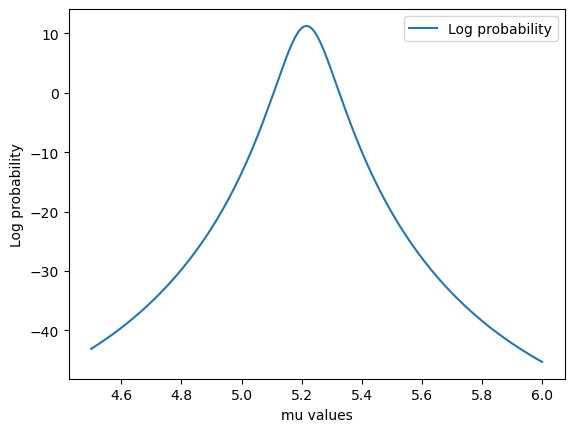

In [22]:
# Fixed sigma
sigma_fixed = 0.8

# Grid of mu values
mu_grid = np.linspace(4.5, 6.0, 200)

log_prob, log_prob_H0, rchi2, linparas, linparas_err = grid_search(
    para_vecs=[mu_grid],
    dataobj=my_instrument,
    fm_func=gaussian_mu_only_fm_func,
    fm_paras={"sigma": sigma_fixed},
    numthreads=None,
    bounds=None
)

# Plot log probability vs mu
plt.figure()
plt.plot(mu_grid, log_prob, label="Log probability")
plt.xlabel("mu values")
plt.ylabel("Log probability")
plt.legend()
plt.show()

### Grid-based approach versus MCMC Sampling

We can now compare the 'grid_search' function, which produces the probabilty of the model marginalized over the linear parameters, to a Markov Chain Monte Carlo (MCMC) simulation posterior distribution. Unlike approaches that rely on computationally expensive samplers like emcee to explore parameter space, breads leverages analytic marginalization to recover equivalent posterior information in less time than running an MCMC chain.

100%|████████████████████████████████████| 2000/2000 [00:05<00:00, 379.25it/s]


<Figure size 800x500 with 0 Axes>

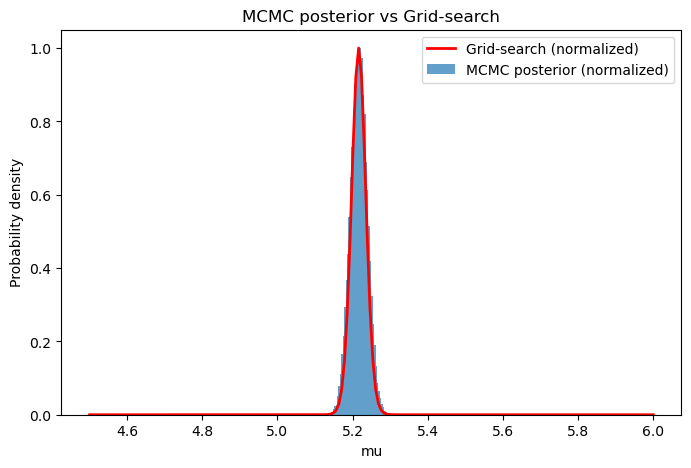

In [14]:
def log_likelihood(mu_array, instrument, sigma):
    """
    Returns log-likelihood for a proposed mu using the Gaussian FM function.
    """
    mu = mu_array[0]  # extract scalar mu
    
    # Gaussian FM function returns y, M (design matrix), s
    y_obs, M, s = gaussian_mu_only_fm_func([mu], instrument, sigma=sigma)
    
    # Solve for linear amplitude A using least squares
    amp, residuals, rank, svals = np.linalg.lstsq(M, y_obs, rcond=None)
    model = M @ amp  # predicted Gaussian values
    
    # Compare model to observed data
    chi2 = np.sum(((y_obs - model)/s)**2)
    
    # Log-likelihood
    return -0.5 * chi2

# MCMC setup
ndim = 1  # only mu is free
nwalkers = 50
nsteps = 2000

# Start walkers near the approximate mu
mu_init = 5.2
p0 = mu_init + 1e-2 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood, args=[my_instrument, sigma_fixed])


# Run MCMC
sampler.run_mcmc(p0, nsteps, progress=True)
samples = sampler.get_chain(flat=True)

# Plot posterior for mu
plt.figure(figsize=(8,5))

# Plot MCMC posterior as histogram
mu_samples = samples[:,0]

# Compute histogram
hist_vals, bin_edges = np.histogram(mu_samples, bins=50, density=True)

# Normalize so the max is 1 (to match grid-search)
hist_vals /= np.max(hist_vals)

# Bin centers for plotting
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.figure(figsize=(8,5))
plt.bar(bin_centers, hist_vals, width=bin_edges[1]-bin_edges[0], alpha=0.7, label='MCMC posterior (normalized)')

# Normalize grid-search probabilities for comparison
grid_prob = np.exp(log_prob - np.max(log_prob))  # exponentiate and normalize
plt.plot(mu_grid, grid_prob, color='red', lw=2, label='Grid-search (normalized)')

plt.xlabel("mu")
plt.ylabel("Probability density")
plt.title("MCMC posterior vs Grid-search")
plt.legend()
plt.show()

In [15]:
imax = np.nanargmax(log_prob)
mu_best = mu_grid[imax]

print("Best-fit mu:", mu_best)

Best-fit mu: 5.21608040201005


In [16]:
results = fitfm(
    nonlin_paras=[mu_best],
    dataobj=my_instrument,        
    fm_func=gaussian_mu_only_fm_func,
    fm_paras={"sigma": sigma_fixed}
)

In [17]:
log_prob, log_prob_H0, rchi2, linparas, linparas_err = results

In [18]:
A = linparas[0]
A_err = linparas_err[0]

print("Amplitude A:", A, "±", A_err)
print("Reduced chi2:", rchi2)

Amplitude A: 4.770126399307184 ± 0.08753796912863519
Reduced chi2: 0.6205713578261557


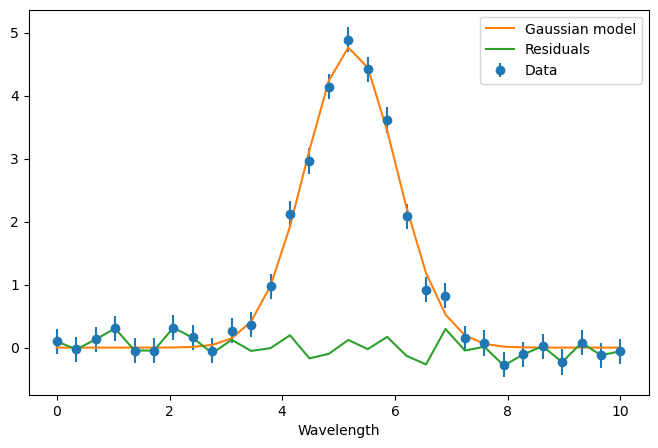

In [19]:
mu_fit, sigma_fit = mu_best, sigma_fixed

# Compute the Gaussian model
model = A * np.exp(-0.5 * ((my_instrument.wavelengths - mu_fit) / sigma_fit) ** 2)

# Plot data, model, and residuals
plt.figure(figsize=(8,5))
plt.errorbar(
    my_instrument.wavelengths,
    my_instrument.data,
    yerr=my_instrument.noise,
    fmt='o',
    label='Data'
)

plt.plot(my_instrument.wavelengths, model, color='tab:orange', label='Gaussian model')
plt.plot(my_instrument.wavelengths, my_instrument.data - model, color='tab:green', label='Residuals')
plt.xlabel("Wavelength")
plt.ylabel("")
plt.legend()
plt.show()